# Posture Detection V2 — 12 Torso-Normalized Retraining + Webcam Validation

Notebook 11 showed two concrete domain mismatches: body scale and webcam left/right convention. This notebook:

1. torso-normalizes the same 57 public features;
2. retrains with the same participant-independent split;
3. saves a new model and transformation contract without overwriting earlier models;
4. tests it using a green-skeleton, five-posture webcam protocol with mirror correction and a core-visibility gate.


## 1. Setup, schema, and normalization

Torso normalization first subtracts the hip midpoint, then divides all coordinates by the shoulder-midpoint-to-hip-midpoint distance. The public data and webcam data use the identical transform.


In [1]:
# Uncomment if needed: %pip install -q mediapipe opencv-python scikit-learn joblib seaborn
import hashlib, json, re, time
from datetime import datetime, timezone
from pathlib import Path

import cv2, joblib, mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit

wd=Path.cwd(); ROOT=wd.parent if wd.name=='notebooks' else wd if wd.name=='project_v2' else wd/'project_v2'
DATA_DIR=ROOT/'data'/'public_multiposture'; RESULT_DIR=ROOT/'results'/'multiposture_torso57'; MODEL_DIR=ROOT/'models'
WEBCAM_DIR=ROOT/'results'/'webcam_sessions'; MODEL_TASK=MODEL_DIR/'pose_landmarker_full.task'; CSV=DATA_DIR/'data.csv'
for d in (RESULT_DIR,MODEL_DIR,WEBCAM_DIR): d.mkdir(parents=True,exist_ok=True)
for p in (CSV,MODEL_TASK):
    if not p.exists(): raise FileNotFoundError(f'Missing {p}. Complete Notebooks 06 and 09 first.')

data=pd.read_csv(CSV); data.columns=[str(c).strip() for c in data.columns]
LANDMARK_NAMES=['nose','left_eye_inner','left_eye','left_eye_outer','right_eye_inner','right_eye','right_eye_outer',
                'left_ear','right_ear','mouth_left','mouth_right','left_shoulder','right_shoulder',
                'left_elbow','right_elbow','left_wrist','right_wrist','left_pinky','right_pinky',
                'left_index','right_index','left_thumb','right_thumb','left_hip','right_hip',
                'left_knee','right_knee','left_ankle','right_ankle','left_heel','right_heel',
                'left_foot_index','right_foot_index']
KEEP_INDICES=list(range(17))+[23,24]; KEEP_NAMES=[LANDMARK_NAMES[i] for i in KEEP_INDICES]
FEATURE_COLUMNS=[f'{name}_{axis}' for name in KEEP_NAMES for axis in 'xyz']; NAME_POS={n:i for i,n in enumerate(KEEP_NAMES)}
LS,RS,LH,RH=[NAME_POS[n] for n in ('left_shoulder','right_shoulder','left_hip','right_hip')]

def torso_normalize_frame(frame):
    a=frame[FEATURE_COLUMNS].to_numpy(np.float32).reshape(-1,len(KEEP_NAMES),3).copy()
    hip=(a[:,LH]+a[:,RH])/2; a-=hip[:,None,:]
    shoulder=(a[:,LS]+a[:,RS])/2; scale=np.linalg.norm(shoulder,axis=1)
    if np.any(scale<1e-6): raise ValueError('Degenerate torso scale detected.')
    a/=scale[:,None,None]
    return pd.DataFrame(a.reshape(len(a),-1),columns=FEATURE_COLUMNS,index=frame.index)

LABEL_MAP={'TUP':'upright','TLB':'lean_backward','TLF':'lean_forward','TLR':'lean_right','TLL':'lean_left'}
y_all=data['upperbody_label'].astype(str).str.strip().str.upper().map(LABEL_MAP)
raw=data[FEATURE_COLUMNS].replace([np.inf,-np.inf],np.nan)
usable=y_all.notna() & raw.notna().all(axis=1) & data['subject'].notna()
X_raw=raw.loc[usable].astype(np.float32); X=torso_normalize_frame(X_raw)
y=y_all.loc[usable]; groups=data.loc[usable,'subject'].astype(str)
digest=hashlib.md5(CSV.read_bytes()).hexdigest()
print('Rows:',len(X),'Features:',X.shape[1],'Participants:',groups.nunique(),'MD5:',digest)
display(y.value_counts().to_frame('frames'))


Rows: 4794 Features: 57 Participants: 13 MD5: 7efbc94d653acf32eefecec3ff26d6c6


,frames
upperbody_label,
lean_forward,1897
upright,1615
lean_backward,442
lean_left,420
lean_right,420


## 2. Identical participant split and public-data evaluation

Random states 42 and 43 reproduce the earlier 8/2/3 participant split, making results comparable with Notebooks 07 and 09.


Validation macro-F1: 0.9781819251160172
{'accuracy': 0.9713178294573643, 'macro_f1': 0.9550213667538167, 'weighted_f1': 0.9708187940361345}
               precision    recall  f1-score   support

lean_backward     0.9630    0.8000    0.8739        65
 lean_forward     0.9765    0.9864    0.9815       590
    lean_left     1.0000    0.9083    0.9520       120
   lean_right     1.0000    1.0000    1.0000       120
      upright     0.9489    0.9873    0.9677       395

     accuracy                         0.9713      1290
    macro avg     0.9777    0.9364    0.9550      1290
 weighted avg     0.9717    0.9713    0.9708      1290



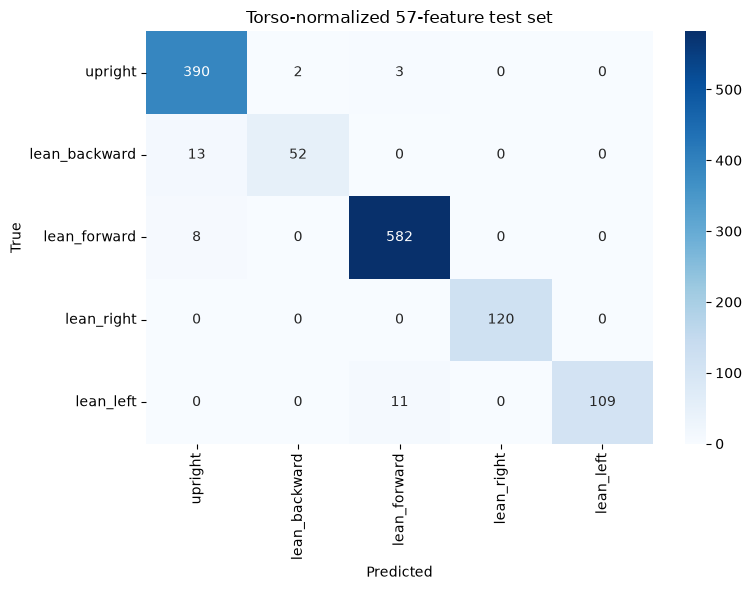

In [2]:
outer=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=42)
trainval_i,test_i=next(outer.split(X,y,groups)); g_tv=groups.iloc[trainval_i]
inner=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=43)
train_i,val_i=next(inner.split(X.iloc[trainval_i],y.iloc[trainval_i],g_tv))
train_idx=np.asarray(trainval_i)[train_i]; val_idx=np.asarray(trainval_i)[val_i]; test_idx=np.asarray(test_i)
assert set(groups.iloc[train_idx]).isdisjoint(groups.iloc[val_idx])
assert set(groups.iloc[train_idx]).isdisjoint(groups.iloc[test_idx])
assert set(groups.iloc[val_idx]).isdisjoint(groups.iloc[test_idx])

model=RandomForestClassifier(n_estimators=500,class_weight='balanced_subsample',min_samples_leaf=2,max_features='sqrt',n_jobs=-1,random_state=42)
model.fit(X.iloc[train_idx],y.iloc[train_idx]); val_pred=model.predict(X.iloc[val_idx])
print('Validation macro-F1:',f1_score(y.iloc[val_idx],val_pred,average='macro'))
fit_idx=np.r_[train_idx,val_idx]; model.fit(X.iloc[fit_idx],y.iloc[fit_idx]); test_pred=model.predict(X.iloc[test_idx])
metrics={'accuracy':float(accuracy_score(y.iloc[test_idx],test_pred)),
         'macro_f1':float(f1_score(y.iloc[test_idx],test_pred,average='macro')),
         'weighted_f1':float(f1_score(y.iloc[test_idx],test_pred,average='weighted'))}
print(metrics); print(classification_report(y.iloc[test_idx],test_pred,digits=4,zero_division=0))
order=list(LABEL_MAP.values()); cm=confusion_matrix(y.iloc[test_idx],test_pred,labels=order)
plt.figure(figsize=(8,6)); sns.heatmap(cm,annot=True,fmt='d',xticklabels=order,yticklabels=order,cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Torso-normalized 57-feature test set'); plt.tight_layout(); plt.show()


## 3. Save the new model and strict transformation contract

OOD ranges are fitted using training and validation participants only. The contract explicitly records torso normalization and webcam mirror correction.


In [3]:
reference=X.iloc[fit_idx]; lower=reference.quantile(.005); upper=reference.quantile(.995)
MODEL_FILE=MODEL_DIR/'multiposture_torso57_rf.joblib'; CONTRACT_FILE=MODEL_DIR/'multiposture_torso57_contract.json'
joblib.dump(model,MODEL_FILE)
contract={'contract_version':3,'created_utc':datetime.now(timezone.utc).isoformat(),
          'source_md5':digest,'participant_column':'subject','upper_label_column':'upperbody_label',
          'landmark_indices':KEEP_INDICES,'landmark_names':KEEP_NAMES,'feature_columns':FEATURE_COLUMNS,
          'public_transform':'hip_center_then_divide_by_shoulder_midpoint_to_hip_midpoint_distance',
          'webcam_transform':'same_torso_normalization_then_horizontal_x_flip_and_left_right_landmark_swap',
          'core_visibility_indices':[11,12,23,24],'minimum_core_visibility':.35,
          'ood_lower_quantile':.005,'ood_upper_quantile':.995,
          'ood_lower':{k:float(v) for k,v in lower.items()},'ood_upper':{k:float(v) for k,v in upper.items()},
          'maximum_ood_fraction':.20,'minimum_probability':.55,'classes':list(model.classes_),
          'label_map':LABEL_MAP,'split_unit':'participant','split_random_states':[42,43],'test_metrics':metrics,
          'limitations':['Prompted webcam poses are diagnostic labels, not independently verified ground truth.',
                         'Production integration requires acceptable webcam OOD coverage and prompted-label behavior.']}
CONTRACT_FILE.write_text(json.dumps(contract,indent=2),encoding='utf-8')
pd.DataFrame({'true':y.iloc[test_idx].to_numpy(),'predicted':test_pred,'participant':groups.iloc[test_idx].to_numpy()}).to_csv(RESULT_DIR/'test_predictions.csv',index=False)
print('Saved:',MODEL_FILE.resolve()); print('Saved:',CONTRACT_FILE.resolve())


Saved: C:\Users\manth\Desktop\project_v2\models\multiposture_torso57_rf.joblib
Saved: C:\Users\manth\Desktop\project_v2\models\multiposture_torso57_contract.json


## 4. Green-skeleton controlled webcam validation

Five phases run automatically: upright, lean forward, lean backward, lean left, and lean right. Each phase has a 3-second preparation period and 8-second recording period.

Move far enough from the camera that both shoulders and both hips are visible. Frames below the core-visibility threshold are displayed but not evaluated. Press **Q** to stop.


In [4]:
CAMERA_INDEX=0; PREP_SECONDS=3; RECORD_SECONDS=8; SAMPLE_EVERY=3
PHASES=['upright','lean_forward','lean_backward','lean_left','lean_right']
MIN_PROB=float(contract['minimum_probability']); MAX_OOD=float(contract['maximum_ood_fraction']); CORE_MIN=float(contract['minimum_core_visibility'])
CORE_INDICES=list(contract['core_visibility_indices']); lower=pd.Series(contract['ood_lower']); upper=pd.Series(contract['ood_upper'])

POSE_CONNECTIONS=[(0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),(11,12),(11,13),(13,15),(15,17),(17,19),(19,15),(15,21),(12,14),(14,16),(16,18),(18,20),(20,16),(16,22),(11,23),(12,24),(23,24),(23,25),(25,27),(27,29),(29,31),(31,27),(24,26),(26,28),(28,30),(30,32),(32,28)]
def draw_skeleton(frame,landmarks,core_ok):
    h,w=frame.shape[:2]; color=(0,255,0) if core_ok else (0,165,255); points=[]
    for p in landmarks:
        visible=min(p.visibility,getattr(p,'presence',p.visibility))>=.35; inside=0<=p.x<=1 and 0<=p.y<=1
        points.append((int(p.x*w),int(p.y*h)) if visible and inside else None)
    for a,b in POSE_CONNECTIONS:
        if points[a] is not None and points[b] is not None: cv2.line(frame,points[a],points[b],color,3,cv2.LINE_AA)
    for point in points:
        if point is not None: cv2.circle(frame,point,4,color,-1,cv2.LINE_AA)

def webcam_features(landmarks):
    xyz=np.array([[p.x,p.y,p.z] for p in landmarks],np.float32); hip=(xyz[23]+xyz[24])/2; xyz-=hip
    shoulder=(xyz[11]+xyz[12])/2; scale=max(float(np.linalg.norm(shoulder)),1e-6); xyz/=scale
    xyz[:,0]*=-1
    for left in [n for n in KEEP_NAMES if n.startswith('left_')]:
        right='right_'+left[5:]
        if right in LANDMARK_NAMES:
            li,ri=LANDMARK_NAMES.index(left),LANDMARK_NAMES.index(right); xyz[[li,ri]]=xyz[[ri,li]]
    values={f'{name}_{axis}':float(xyz[i,j]) for i,name in zip(KEEP_INDICES,KEEP_NAMES) for j,axis in enumerate('xyz')}
    return pd.DataFrame([[values[c] for c in FEATURE_COLUMNS]],columns=FEATURE_COLUMNS)

Base=mp.tasks.BaseOptions; Landmarker=mp.tasks.vision.PoseLandmarker; Options=mp.tasks.vision.PoseLandmarkerOptions; Mode=mp.tasks.vision.RunningMode
opts=Options(base_options=Base(model_asset_path=str(MODEL_TASK)),running_mode=Mode.VIDEO,num_poses=1,min_pose_detection_confidence=.5,min_pose_presence_confidence=.5,min_tracking_confidence=.5)
cap=cv2.VideoCapture(CAMERA_INDEX); cap.set(cv2.CAP_PROP_FRAME_WIDTH,1280); cap.set(cv2.CAP_PROP_FRAME_HEIGHT,720)
if not cap.isOpened(): raise RuntimeError('Could not open webcam.')
records=[]; rejected_visibility=0; frame_id=0; stop=False; started=time.perf_counter()
with Landmarker.create_from_options(opts) as detector:
  try:
    for phase in PHASES:
      prep=time.perf_counter()
      while time.perf_counter()-prep<PREP_SECONDS:
        ok,frame=cap.read()
        if not ok: stop=True; break
        frame=cv2.flip(frame,1); now=time.perf_counter(); ts=int((now-started)*1000)
        result=detector.detect_for_video(mp.Image(image_format=mp.ImageFormat.SRGB,data=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)),ts)
        if result.pose_landmarks:
          lm=result.pose_landmarks[0]; core=min(min(lm[i].visibility,getattr(lm[i],'presence',lm[i].visibility)) for i in CORE_INDICES); draw_skeleton(frame,lm,core>=CORE_MIN)
        remain=PREP_SECONDS-(now-prep); cv2.putText(frame,f'GET READY: {phase.replace("_"," ").upper()}',(25,50),cv2.FONT_HERSHEY_SIMPLEX,.9,(0,200,255),2); cv2.putText(frame,f'{max(1,int(np.ceil(remain)))}',(25,90),cv2.FONT_HERSHEY_SIMPLEX,.8,(255,255,255),2); cv2.imshow('Notebook 12 Validation',frame)
        if cv2.waitKey(1)&0xFF==ord('q'): stop=True; break
      if stop: break
      phase_start=time.perf_counter()
      while time.perf_counter()-phase_start<RECORD_SECONDS:
        ok,frame=cap.read()
        if not ok: stop=True; break
        frame=cv2.flip(frame,1); now=time.perf_counter(); ts=int((now-started)*1000)
        result=detector.detect_for_video(mp.Image(image_format=mp.ImageFormat.SRGB,data=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)),ts); detected=bool(result.pose_landmarks); core=0.; message='NO POSE'
        if detected:
          lm=result.pose_landmarks[0]; core=float(min(min(lm[i].visibility,getattr(lm[i],'presence',lm[i].visibility)) for i in CORE_INDICES)); core_ok=core>=CORE_MIN; draw_skeleton(frame,lm,core_ok)
          if core_ok:
            x=webcam_features(lm); ood=float(((x.iloc[0]<lower)|(x.iloc[0]>upper)).mean()); probs=model.predict_proba(x)[0]; k=int(np.argmax(probs)); label=str(model.classes_[k]); prob=float(probs[k]); accepted=prob>=MIN_PROB and ood<=MAX_OOD; message=f'{label} {prob:.0%} OOD:{ood:.0%}'
            if frame_id%SAMPLE_EVERY==0: records.append({'phase':phase,'seconds':now-started,'core_visibility':core,'predicted':label,'probability':prob,'ood_fraction':ood,'accepted':accepted})
          else: rejected_visibility+=1; message=f'MOVE BACK / SHOW HIPS  core:{core:.0%}'
        remain=RECORD_SECONDS-(now-phase_start); color=(0,255,0) if detected and core>=CORE_MIN else (0,165,255)
        cv2.putText(frame,f'RECORD: {phase.replace("_"," ").upper()}  {remain:.1f}s',(25,45),cv2.FONT_HERSHEY_SIMPLEX,.8,color,2); cv2.putText(frame,message,(25,85),cv2.FONT_HERSHEY_SIMPLEX,.65,(255,255,255),2); cv2.putText(frame,'Q: stop',(25,frame.shape[0]-25),cv2.FONT_HERSHEY_SIMPLEX,.55,(255,255,255),1); cv2.imshow('Notebook 12 Validation',frame)
        if cv2.waitKey(1)&0xFF==ord('q'): stop=True; break
        frame_id+=1
      if stop: break
  finally: cap.release(); cv2.destroyAllWindows()

session=pd.DataFrame(records)
if session.empty: raise RuntimeError('No frames passed the core-visibility gate. Move farther back and rerun this cell.')
stamp=datetime.now().strftime('%Y%m%d_%H%M%S'); out=WEBCAM_DIR/f'torso57_validation_{stamp}.csv'; session.to_csv(out,index=False)
print('Saved:',out.resolve()); print('Visibility-rejected frames:',rejected_visibility)
display(pd.crosstab(session['phase'],session['predicted']))
summary=session.groupby('phase').agg(samples=('predicted','size'),median_probability=('probability','median'),median_ood=('ood_fraction','median'),accepted_percent=('accepted',lambda s:s.mean()*100))
display(summary)
overall=pd.Series({'samples':len(session),'median_probability':session['probability'].median(),'median_ood_fraction':session['ood_fraction'].median(),'ood_pass_percent':session['ood_fraction'].le(MAX_OOD).mean()*100,'accepted_prediction_percent':session['accepted'].mean()*100,'prompted_label_match_percent':session['phase'].eq(session['predicted']).mean()*100})
display(overall.to_frame('value'))


Saved: C:\Users\manth\Desktop\project_v2\results\webcam_sessions\torso57_validation_20260925_004011.csv
Visibility-rejected frames: 22


predicted,lean_forward,lean_left,lean_right,upright
phase,,,,
lean_backward,7,0,6,1
lean_forward,13,0,0,0
lean_left,3,12,0,0
lean_right,2,0,12,0
upright,8,0,0,2


,samples,median_probability,median_ood,accepted_percent
phase,,,,
lean_backward,14,0.686991,0.105263,57.142857
lean_forward,13,0.756505,0.035088,100.000000
lean_left,15,0.889235,0.087719,100.000000
lean_right,14,0.739219,0.087719,100.000000
upright,10,0.736475,0.061404,80.000000


,value
samples,66.000000
median_probability,0.750856
median_ood_fraction,0.070175
ood_pass_percent,90.909091
accepted_prediction_percent,87.878788
prompted_label_match_percent,59.090909


## What to send back

Send the executed notebook. We will verify public test macro-F1, webcam OOD coverage, accepted-prediction coverage, left/right correction, upright behavior, and the number of visibility-rejected frames before building the production hybrid integration.
